# III> Bài tập nâng cao
1. Phát hiện cạnh: Sử dụng các kernel Sobel, Prewitt để phát hiện các cạnh trong ảnh.
2. Tự thiết kế kernel: Tạo các kernel tùy chỉnh để đạt được các hiệu ứng khác nhau.
3. So sánh các loại lọc: So sánh hiệu quả của các loại lọc khác nhau trên cùng một hình ảnh.
4. Áp dụng lọc phi tuyến tính: Tìm hiểu về các loại lọc không tuyến tính như median filter, bilateral filter
# 1. Phát hiện cạnh: Sử dụng các kernel Sobel, Prewitt để phát hiện các cạnh trong ảnh.

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Cấu hình các đường dẫn theo yêu cầu của bạn
BASE_DIR = Path(".").resolve()
IMAGE_PATH = BASE_DIR / "images" / "input.jpg"
OUTPUT_ROOT = BASE_DIR / "output" / "bai3"

# Đảm bảo thư mục lưu kết quả đầu ra luôn tồn tại
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# Hàm hiển thị kết quả nhiều ảnh song song trực quan - ĐÃ ẨN TOÀN BỘ TỌA ĐỘ
def show_images(titles, images, cmap='gray'):
    n = len(images)
    plt.figure(figsize=(6 * n, 5))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        if len(images[i].shape) == 2:
            plt.imshow(images[i], cmap=cmap)
        else:
            plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
        plt.title(titles[i], fontsize=12, pad=10)
        
        # Tắt hiển thị các trục và số tọa độ xung quanh hình ảnh
        plt.axis('off') 
        
    plt.tight_layout()
    plt.show()

# Đọc ảnh gốc đầu vào
img_original = cv2.imread(str(IMAGE_PATH))
if img_original is None:
    raise FileNotFoundError(f"Không tìm thấy ảnh đầu vào tại: {IMAGE_PATH}")
else:
    gray = cv2.cvtColor(img_original, cv2.COLOR_BGR2GRAY)
    print("Đã tải ảnh gốc và sẵn sàng xử lý!")

Đã tải ảnh gốc và sẵn sàng xử lý!


- Thuật toán Sobel 

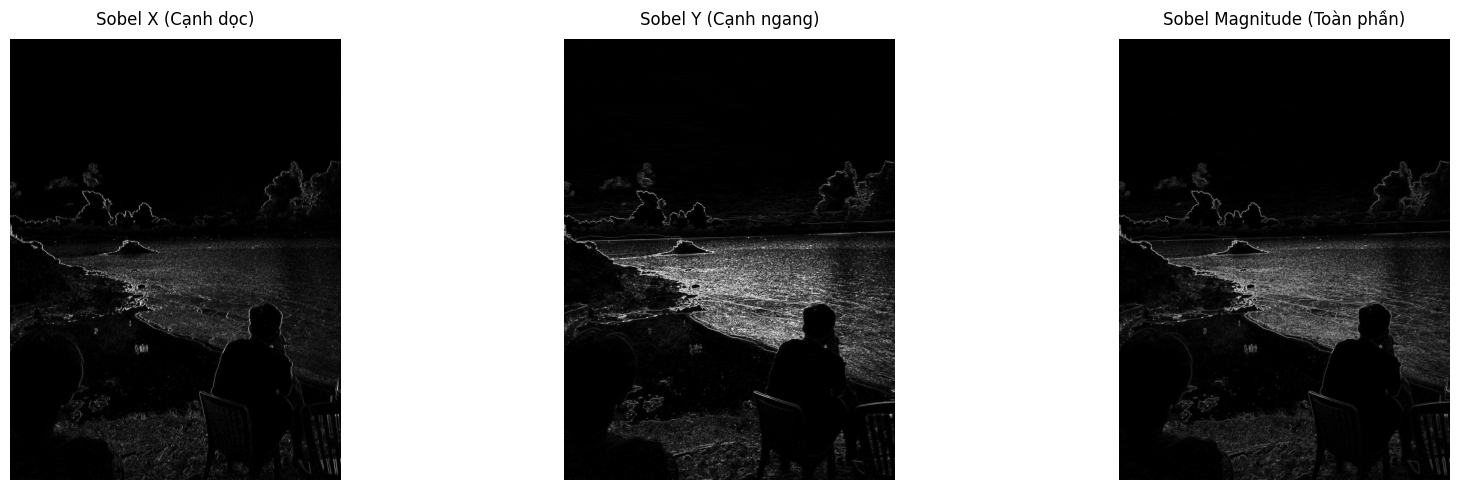

In [23]:
if img_original is not None:
    # Tính toán đạo hàm số theo trục X và Y dựa vào bộ lọc Sobel
    grad_x = cv2.Sobel(gray, cv2.CV_16S, 1, 0, ksize=3)
    grad_y = cv2.Sobel(gray, cv2.CV_16S, 0, 1, ksize=3)
    
    # Chuyển đổi kết quả về dạng ảnh 8-bit tuyệt đối
    sobel_x = cv2.convertScaleAbs(grad_x)
    sobel_y = cv2.convertScaleAbs(grad_y)
    
    # Kết hợp hai thành phần X và Y để tính độ lớn biên độ toàn phần
    sobel_mag = cv2.convertScaleAbs(cv2.addWeighted(sobel_x, 0.5, sobel_y, 0.5, 0))
    
    # Lưu kết quả trực tiếp vào folder đầu ra của bạn
    cv2.imwrite(str(OUTPUT_ROOT / "sobel_x.jpg"), sobel_x)
    cv2.imwrite(str(OUTPUT_ROOT / "sobel_y.jpg"), sobel_y)
    cv2.imwrite(str(OUTPUT_ROOT / "sobel_magnitude.jpg"), sobel_mag)
    
    # Hiển thị trực quan kết quả biên cạnh sạch sẽ, không chứa vạch số tọa độ
    show_images(
        ["Sobel X (Cạnh dọc)", "Sobel Y (Cạnh ngang)", "Sobel Magnitude (Toàn phần)"],
        [sobel_x, sobel_y, sobel_mag]
    )

- Toán tử Prewitt

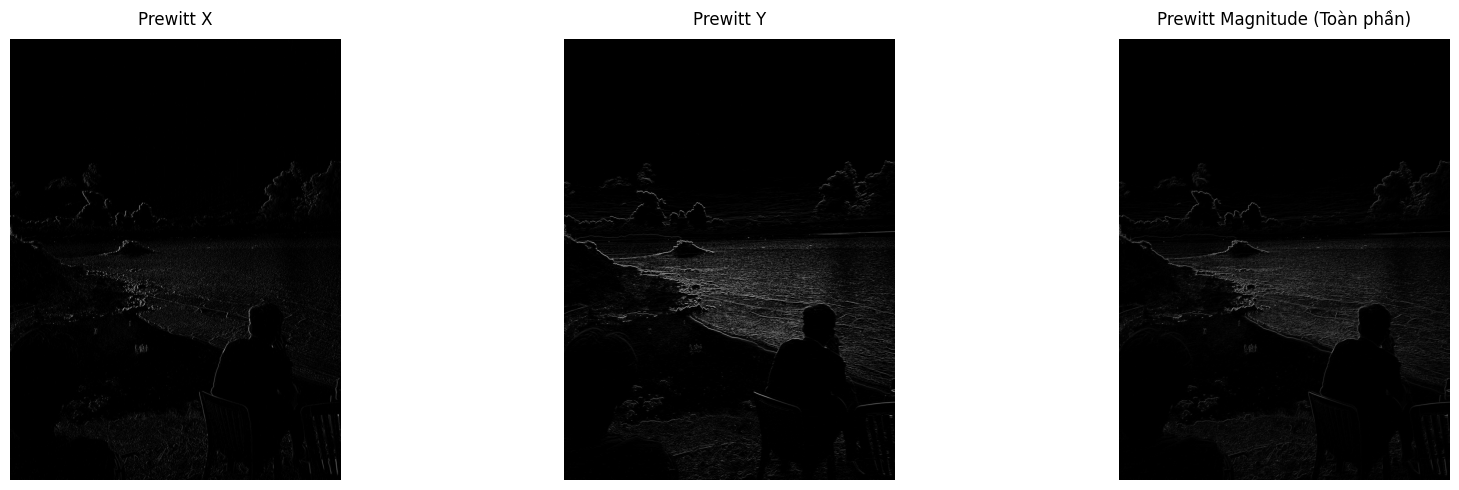

In [24]:
if img_original is not None:
    # Định nghĩa ma trận bộ lọc Prewitt thủ công theo hướng X và hướng Y
    kernel_x = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]], dtype=np.float32)
    kernel_y = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=np.float32)
    
    # Áp dụng bộ lọc tích chập filter2D
    prewitt_x = cv2.filter2D(gray, -1, kernel_x)
    prewitt_y = cv2.filter2D(gray, -1, kernel_y)
    
    # Tính độ lớn biên độ biên cạnh toàn phần
    prewitt_mag = cv2.convertScaleAbs(cv2.addWeighted(prewitt_x, 0.5, prewitt_y, 0.5, 0))
    
    # Lưu kết quả trực tiếp vào folder đầu ra
    cv2.imwrite(str(OUTPUT_ROOT / "prewitt_x.jpg"), prewitt_x)
    cv2.imwrite(str(OUTPUT_ROOT / "prewitt_y.jpg"), prewitt_y)
    cv2.imwrite(str(OUTPUT_ROOT / "prewitt_magnitude.jpg"), prewitt_mag)
    
    # Hiển thị kết quả sạch không tọa độ
    show_images(
        ["Prewitt X", "Prewitt Y", "Prewitt Magnitude (Toàn phần)"],
        [prewitt_x, prewitt_y, prewitt_mag]
    )

## 2. Tự thiết kế kernel: Tạo các kernel tùy chỉnh để đạt được các hiệu ứng khác nhau.

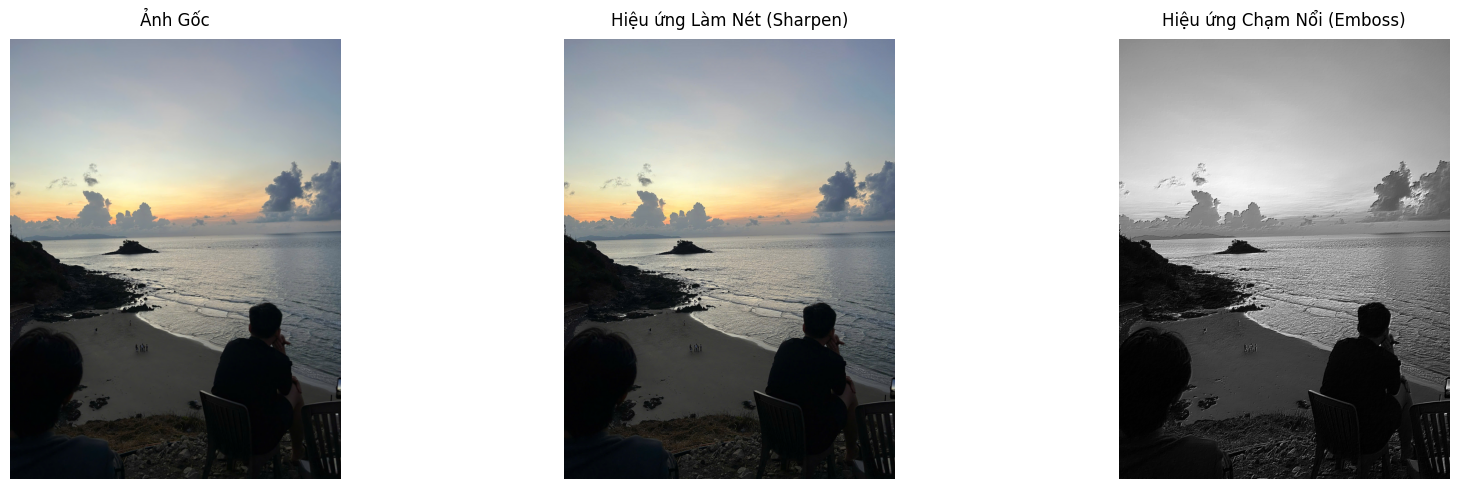

In [25]:
if img_original is not None:
    # Thiết kế ma trận Kernel Làm nét (Sharpen) và Chạm nổi (Emboss) nâng cao
    kernel_sharpen = np.array([[ 0, -1,  0], 
                               [-1,  5, -1], 
                               [ 0, -1,  0]], dtype=np.float32)
                               
    kernel_emboss = np.array([[-2, -1,  0], 
                              [-1,  1,  1], 
                              [ 0,  1,  2]], dtype=np.float32)
    
    # Thực hiện lọc biến đổi hiệu ứng hình ảnh bằng filter2D
    sharpen_img = cv2.filter2D(img_original, -1, kernel_sharpen)
    emboss_img = cv2.filter2D(gray, -1, kernel_emboss)
    
    # Lưu kết quả vào folder đầu ra
    cv2.imwrite(str(OUTPUT_ROOT / "custom_sharpen.jpg"), sharpen_img)
    cv2.imwrite(str(OUTPUT_ROOT / "custom_emboss.jpg"), emboss_img)
    
    # Hiển thị hình ảnh thuần túy bóng bẩy
    show_images(
        ["Ảnh Gốc", "Hiệu ứng Làm Nét (Sharpen)", "Hiệu ứng Chạm Nổi (Emboss)"],
        [img_original, sharpen_img, emboss_img]
    )

## 3. So sánh các loại lọc: So sánh hiệu quả của các loại lọc khác nhau trên cùng một hình ảnh.

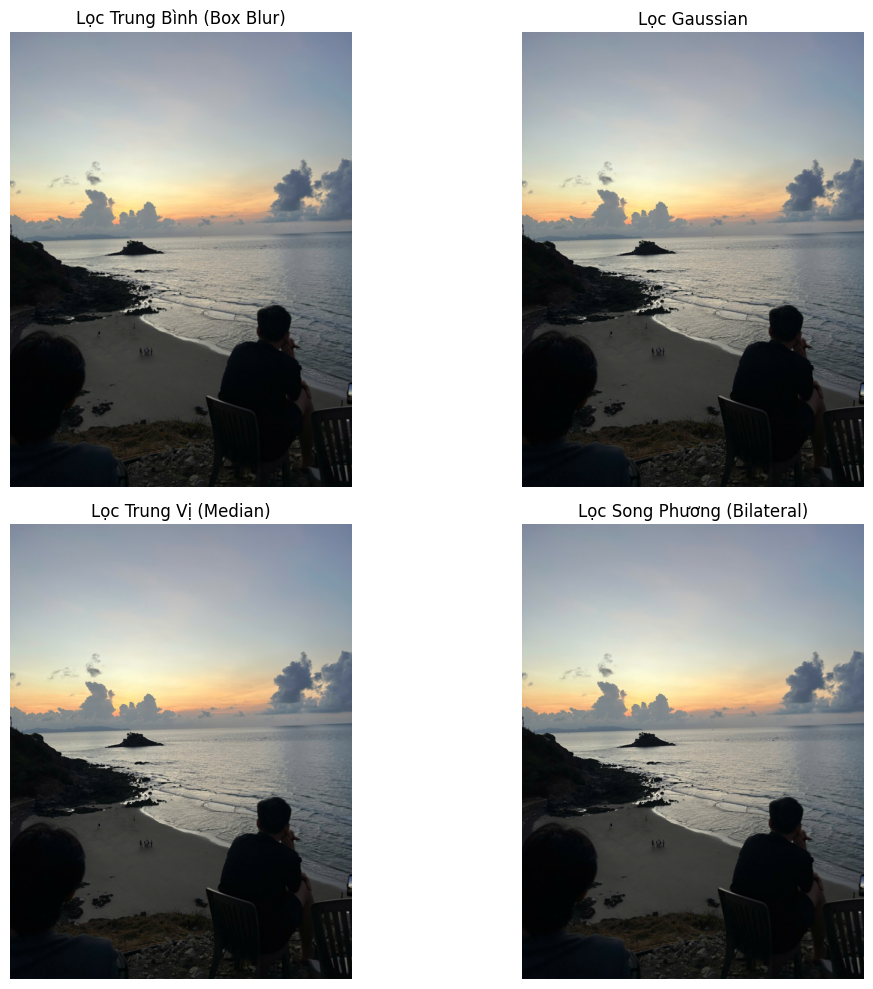

In [26]:
if img_original is not None:
    # Áp dụng đồng thời 4 phương pháp lọc khác nhau lên cùng một ảnh gốc
    blur_box = cv2.blur(img_original, (5, 5))
    blur_gaussian = cv2.GaussianBlur(img_original, (5, 5), 0)
    blur_median = cv2.medianBlur(img_original, 5) # Trích xuất từ bài Bai_03_03.py
    blur_bilateral = cv2.bilateralFilter(img_original, 9, 75, 75) # Trích xuất từ bài Bai_03_04.py
    
    # Lưu toàn bộ các file ảnh bộ lọc vào folder đầu ra
    cv2.imwrite(str(OUTPUT_ROOT / "filter_box.jpg"), blur_box)
    cv2.imwrite(str(OUTPUT_ROOT / "filter_gaussian.jpg"), blur_gaussian)
    cv2.imwrite(str(OUTPUT_ROOT / "filter_median.jpg"), blur_median)
    cv2.imwrite(str(OUTPUT_ROOT / "filter_bilateral.jpg"), blur_bilateral)
    
    # Vẽ biểu đồ lưới 2x2 loại bỏ hoàn toàn các vạch số trên trục x, y
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    axes[0, 0].imshow(cv2.cvtColor(blur_box, cv2.COLOR_BGR2RGB)), axes[0, 0].set_title('Lọc Trung Bình (Box Blur)')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(cv2.cvtColor(blur_gaussian, cv2.COLOR_BGR2RGB)), axes[0, 1].set_title('Lọc Gaussian')
    axes[0, 1].axis('off')
    
    axes[1, 0].imshow(cv2.cvtColor(blur_median, cv2.COLOR_BGR2RGB)), axes[1, 0].set_title('Lọc Trung Vị (Median)')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(cv2.cvtColor(blur_bilateral, cv2.COLOR_BGR2RGB)), axes[1, 1].set_title('Lọc Song Phương (Bilateral)')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

## 4. Áp dụng lọc phi tuyến tính: Tìm hiểu về các loại lọc không tuyến tính như median filter, bilateral filter.

- Bộ lọc Trung vị - Median Filter

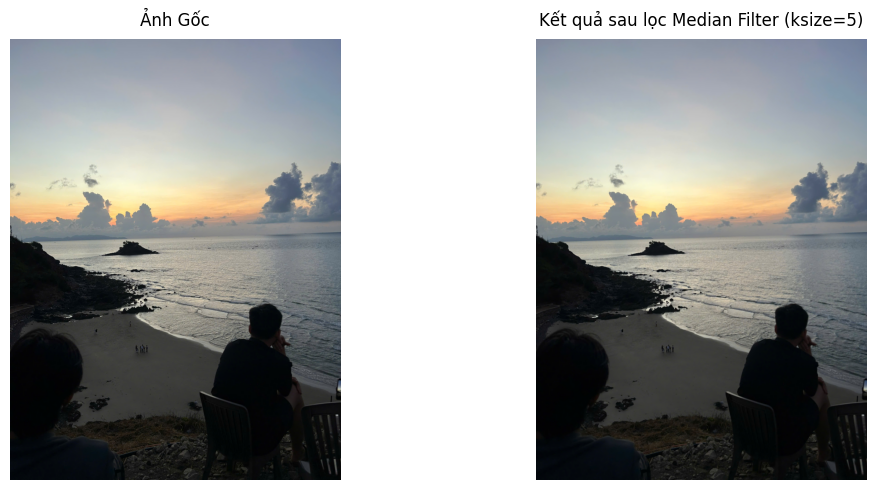

In [27]:
if img_original is not None:
    # Thực hiện bộ lọc phi tuyến tính trung vị với kích thước kernel bằng 5
    median_blur = cv2.medianBlur(img_original, 5)
    
    # Lưu kết quả
    cv2.imwrite(str(OUTPUT_ROOT / "median.jpg"), median_blur)
    
    # Hiển thị ảnh trơn không chứa vạch số tọa độ
    show_images(
        ["Ảnh Gốc", "Kết quả sau lọc Median Filter (ksize=5)"],
        [img_original, median_blur]
    )

- Bộ lọc Song phương - Bilateral Filte

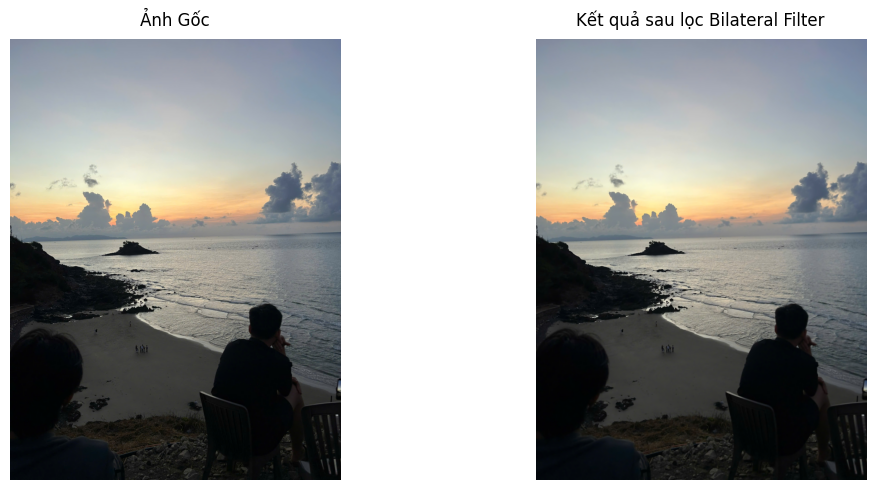

In [28]:
if img_original is not None:
    # Thực hiện bộ lọc song phương phi tuyến tính bảo toàn cạnh
    bilateral_blur = cv2.bilateralFilter(img_original, 9, 75, 75)
    
    # Lưu kết quả
    cv2.imwrite(str(OUTPUT_ROOT / "bilateral.jpg"), bilateral_blur)
    
    # Hiển thị ảnh trơn không chứa vạch số tọa độ
    show_images(
        ["Ảnh Gốc", "Kết quả sau lọc Bilateral Filter"],
        [img_original, bilateral_blur]
    )